=== Polymer Counts ===
polymer_primary
PVDF     351
PVA      141
PVP       95
PAN       62
PS        45
PCL       26
PMMA      20
Y_PGA     18
PDLLA     16
CA        15
PET       12
PLA        8
Name: count, dtype: int64


/tmp/ipython-input-1806882498.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=polymer_counts.index, y=polymer_counts.values, palette='viridis')


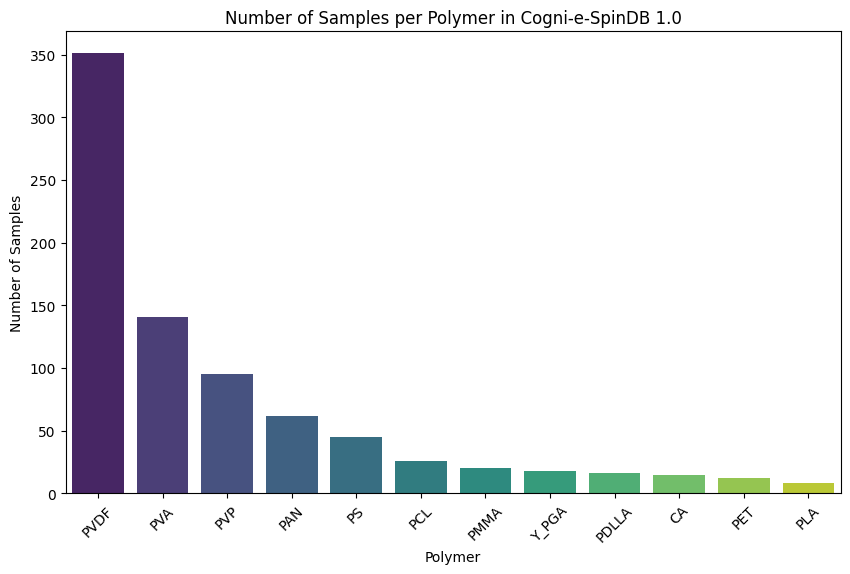


Polymers with enough data for polymer-specific regression:
polymer_primary
PVDF    351
PVA     141
PVP      95
PAN      62
PS       45
PCL      26
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Cogni-e-SpinDB 1.0.csv")

# Extract primary polymer
df['polymer_primary'] = df['polymer(s)'].astype(str).str.split(r'[;,/|]').str[0].str.strip()

# Count samples per polymer
polymer_counts = df['polymer_primary'].value_counts()
print("=== Polymer Counts ===")
print(polymer_counts)

# Visualize polymer distribution
plt.figure(figsize=(10,6))
sns.barplot(x=polymer_counts.index, y=polymer_counts.values, palette='viridis')
plt.xticks(rotation=45)
plt.xlabel("Polymer")
plt.ylabel("Number of Samples")
plt.title("Number of Samples per Polymer in Cogni-e-SpinDB 1.0")
plt.show()

# Identify polymers suitable for modeling (>20 samples)
sufficient_data = polymer_counts[polymer_counts > 20]
print("\nPolymers with enough data for polymer-specific regression:")
print(sufficient_data)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Cogni-e-SpinDB 1.0.csv")

# Extract primary polymer
df['polymer_primary'] = df['polymer(s)'].astype(str).str.split(r'[;,/|]').str[0].str.strip()

# Filter PAN samples
pan_df = df[df['polymer_primary'] == "PAN"].copy()

print("Total PAN samples:", len(pan_df))


Total PAN samples: 62


In [ ]:
# Convert numeric-like columns
for col in ['temperature_c', 'humidity_%', 'flow_rate_ml/h',
            'voltage_kv', 'tip_collector_distance_cm',
            'solution_concentration']:
    pan_df[col] = pd.to_numeric(pan_df[col], errors='coerce')

# Convert booleans
for col in ['is_solvent_blend', 'was_formation_stable', 'tail_observation']:
    if col in pan_df.columns:
        pan_df[col] = pan_df[col].astype(int)

# Drop rows without fiber diameter
pan_df = pan_df[pan_df['fiber_diameter_nm'].notna()].reset_index(drop=True)

print("Clean PAN dataset size:", len(pan_df))


Clean PAN dataset size: 62


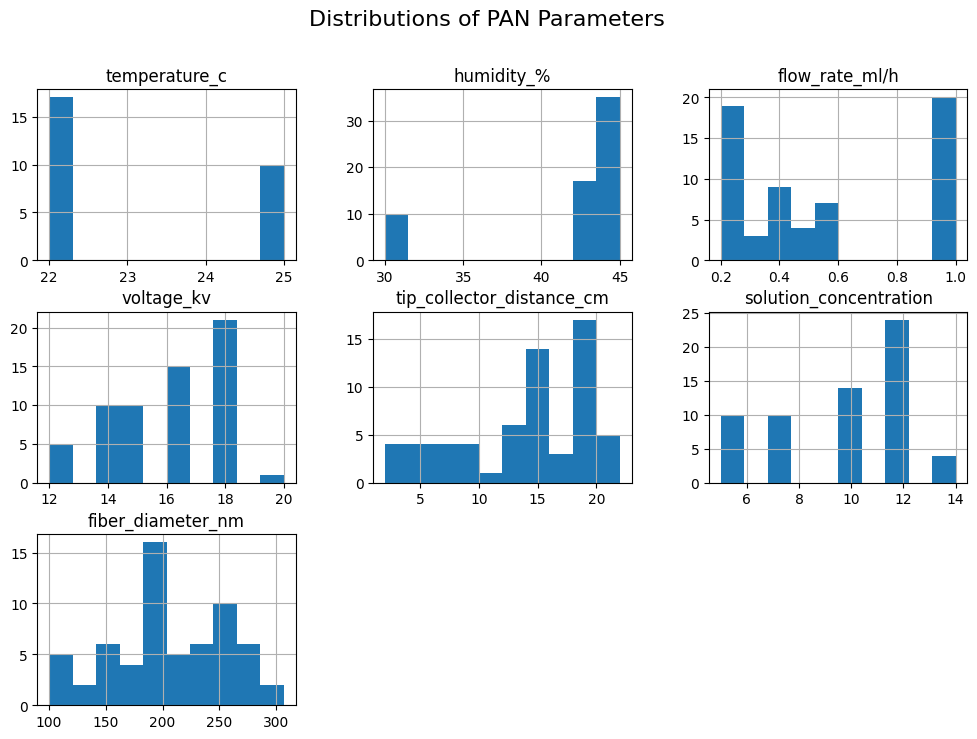

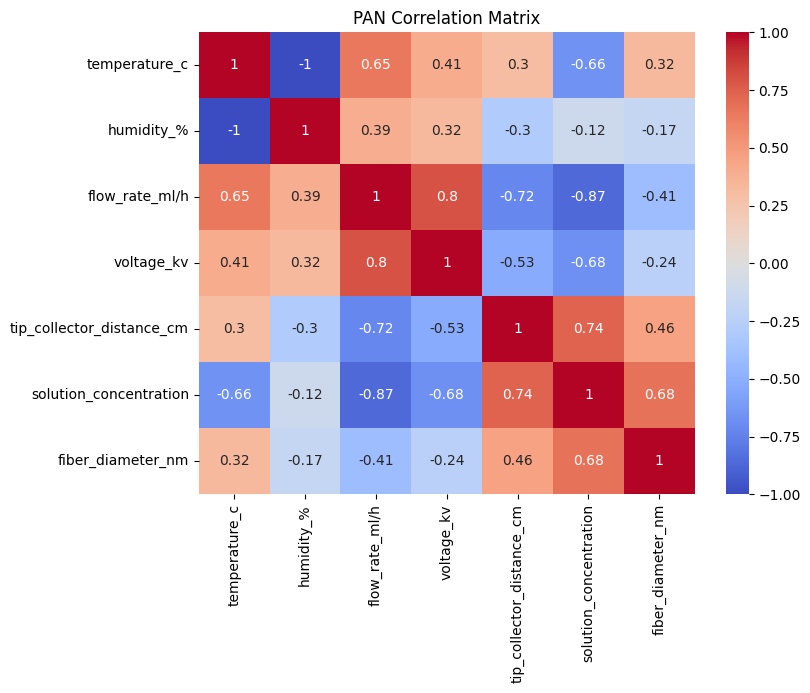

In [ ]:
numeric_cols = ['temperature_c', 'humidity_%', 'flow_rate_ml/h',
                'voltage_kv', 'tip_collector_distance_cm',
                'solution_concentration', 'fiber_diameter_nm']

# Histograms
pan_df[numeric_cols].hist(figsize=(12,8))
plt.suptitle("Distributions of PAN Parameters", fontsize=16)
plt.show()

# Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(pan_df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("PAN Correlation Matrix")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


CV R²: 0.587 ± 0.208
CV RMSE (log-scale): 0.160 ± 0.042


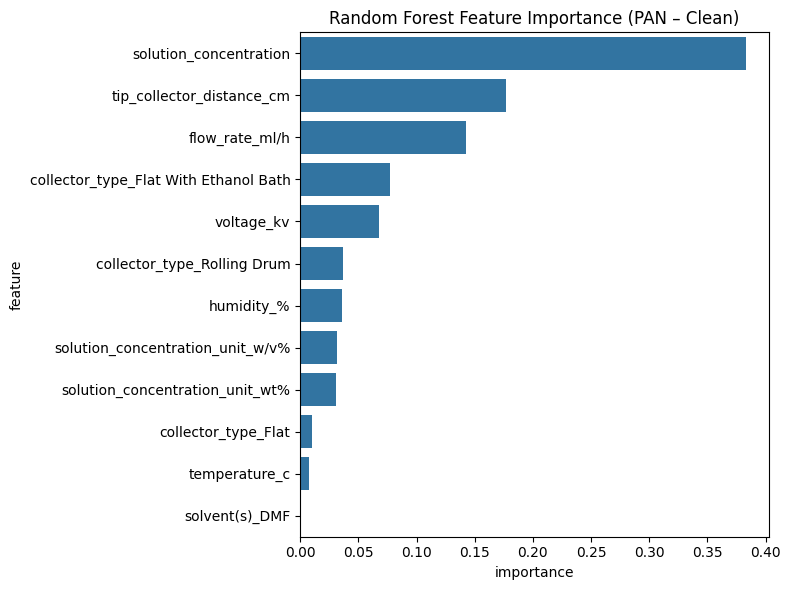


RECOMMENDED ELECTROSPINNING PARAMETERS:


,is_solvent_blend,solvent(s),solution_concentration,solution_concentration_unit,needle_type,collector_type,voltage_kv,flow_rate_ml/h,tip_collector_distance_cm,temperature_c,humidity_%,was_formation_stable,tail_observation,polymer_primary
0,False,DMF,9.683234,wt%,Single Needle,Rolling Drum,30.0,0.1,8.0,23.810901,60.0,True,False,PAN


Predicted diameter: 198.47 nm
Uncertainty (std): ±17.52 nm
90% CI: [175.55682128 232.52796917]


In [ ]:
# ============================================================
# STEP 0: Install dependencies (Colab)
# ============================================================
!pip install -q scikit-learn scikit-optimize

# ============================================================
# STEP 1: Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# STEP 2: Load dataset
# ============================================================
df = pd.read_csv("/content/drive/MyDrive/Cogni-e-SpinDB 1.0.csv")

# ============================================================
# STEP 3: Extract primary polymer & filter PAN
# ============================================================
df["polymer_primary"] = (
    df["polymer(s)"]
    .astype(str)
    .str.split(r"[;,/|]")
    .str[0]
    .str.strip()
)

df = df[df["polymer_primary"] == "PAN"].copy()

# ============================================================
# STEP 4: Numeric cleanup
# ============================================================
num_cols = [
    "voltage_kv",
    "flow_rate_ml/h",
    "tip_collector_distance_cm",
    "solution_concentration",
    "temperature_c",
    "humidity_%"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df[df["fiber_diameter_nm"].notna()].reset_index(drop=True)

# ============================================================
# STEP 5: Define TARGET and REMOVE LEAKAGE ❗
# ============================================================
TARGET_COL = "fiber_diameter_nm"

drop_cols = [
    TARGET_COL,                     # 🚨 CRITICAL
    "fiber_diameter_variation_nm",
    "rotation_speed_rpm",
    "needle_diameter_g",
    "doi",
    "polymer(s)",
    "solvent_components"
]

X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
y = df[TARGET_COL]

# Log-transform target (consistent everywhere)
y_log = np.log1p(y)

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

# ============================================================
# STEP 6: Preprocessing (SINGLE SOURCE OF TRUTH)
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# ============================================================
# STEP 7: Random Forest surrogate
# ============================================================
rf_model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=800,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

# ============================================================
# STEP 8: Cross-validation (reporting)
# ============================================================
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(rf_model, X, y_log, cv=cv, scoring="r2")
rmse_scores = np.sqrt(
    -cross_val_score(rf_model, X, y_log, cv=cv,
                     scoring="neg_mean_squared_error")
)

print(f"CV R²: {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"CV RMSE (log-scale): {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")

# ============================================================
# STEP 9: Fit final surrogate
# ============================================================
rf_model.fit(X, y_log)

# ============================================================
# STEP 10: Feature importance (LEAKAGE-FREE)
# ============================================================
rf = rf_model.named_steps["rf"]
ohe = rf_model.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(cat_cols)

features = numeric_cols + list(cat_names)

imp = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=imp.head(12), x="importance", y="feature")
plt.title("Random Forest Feature Importance (PAN – Clean)")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 11: Bootstrap uncertainty (CORRECT)
# ============================================================
def bootstrap_predict(X_train, y_train, X_query, n_boot=100):
    preds = []

    for _ in range(n_boot):
        idx = np.random.choice(len(X_train), len(X_train), replace=True)
        X_b = X_train.iloc[idx]
        y_b = y_train.iloc[idx]

        model_b = Pipeline([
            ("prep", preprocessor),
            ("rf", RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=None,
                n_jobs=-1
            ))
        ])

        model_b.fit(X_b, y_b)
        preds.append(model_b.predict(X_query)[0])

    return np.array(preds)

# ============================================================
# STEP 12: Bayesian Optimization (inverse design)
# ============================================================
TARGET_DIAMETER = 200
UNCERTAINTY_WEIGHT = 0.4

space = [
    Real(8, 30, name="voltage_kv"),
    Real(0.1, 2.0, name="flow_rate_ml/h"),
    Real(8, 25, name="tip_collector_distance_cm"),
    Real(8, 25, name="solution_concentration"),
    Real(22, 35, name="temperature_c"),
    Real(20, 60, name="humidity_%")
]

X_template = X.copy()

def build_row(params):
    row = {}
    for col in X_template.columns:
        if col in params:
            row[col] = params[col]
        elif col in numeric_cols:
            row[col] = X_template[col].median()
        else:
            row[col] = X_template[col].mode()[0]
    return pd.DataFrame([row])[X_template.columns]

@use_named_args(space)
def objective(**params):
    X_q = build_row(params)
    preds_log = bootstrap_predict(X, y_log, X_q, n_boot=50)
    preds_nm = np.expm1(preds_log)

    return abs(preds_nm.mean() - TARGET_DIAMETER) + \
           UNCERTAINTY_WEIGHT * preds_nm.std()

# ============================================================
# STEP 13: Run BO
# ============================================================
res = gp_minimize(
    objective,
    space,
    n_calls=40,
    n_initial_points=10,
    random_state=42
)

# ============================================================
# STEP 14: Final recommendation
# ============================================================
best_params = {dim.name: val for dim, val in zip(space, res.x)}
best_row = build_row(best_params)

final_preds_log = bootstrap_predict(X, y_log, best_row, n_boot=300)
final_preds_nm = np.expm1(final_preds_log)

print("\nRECOMMENDED ELECTROSPINNING PARAMETERS:")
display(best_row)

print(f"Predicted diameter: {final_preds_nm.mean():.2f} nm")
print(f"Uncertainty (std): ±{final_preds_nm.std():.2f} nm")
print("90% CI:", np.percentile(final_preds_nm, [5, 95]))


In [ ]:
def bootstrap_predict(model, X, y_log, X_query, n_boot=80):
    preds = []

    for _ in range(n_boot):
        idx = np.random.choice(len(X), len(X), replace=True)
        X_b = X.iloc[idx]
        y_b = y_log.iloc[idx]

        model_b = Pipeline([
            ("prep", preprocessor),
            ("rf", RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=None,
                n_jobs=-1
            ))
        ])

        model_b.fit(X_b, y_b)
        preds.append(model_b.predict(X_query)[0])

    return np.array(preds)


In [ ]:
TARGET_DIAMETER = 200  # nm
UNCERTAINTY_WEIGHT = 0.2  # reduced (critical)
BOUNDARY_WEIGHT = 3.0     # soft interior penalty

space = [
    Real(10, 28, name="voltage_kv"),
    Real(0.2, 1.2, name="flow_rate_ml/h"),
    Real(10, 20, name="tip_collector_distance_cm"),
    Real(10, 22, name="solution_concentration"),
    Real(23, 32, name="temperature_c"),
    Real(30, 55, name="humidity_%")
]


In [ ]:
X_template = X.copy()

def build_row(params):
    row = {}
    for col in X_template.columns:
        if col in params:
            row[col] = params[col]
        elif col in numeric_cols:
            row[col] = X_template[col].median()
        else:
            row[col] = X_template[col].mode()[0]
    return pd.DataFrame([row])[X_template.columns]


In [ ]:
@use_named_args(space)
def objective(**params):
    X_q = build_row(params)

    preds_log = bootstrap_predict(
        rf_model, X, y_log, X_q, n_boot=60
    )

    preds_nm = np.expm1(preds_log)
    mean = preds_nm.mean()
    std = preds_nm.std()

    # Primary inverse loss
    loss = abs(mean - TARGET_DIAMETER)

    # Uncertainty penalty
    loss += UNCERTAINTY_WEIGHT * std

    # Soft interior penalty (prevents boundary collapse)
    boundary_penalty = 0
    for dim in space:
        mid = (dim.low + dim.high) / 2
        span = (dim.high - dim.low) / 2
        boundary_penalty += abs(params[dim.name] - mid) / span

    loss += BOUNDARY_WEIGHT * boundary_penalty

    return loss


In [ ]:
res = gp_minimize(
    objective,
    space,
    n_calls=40,
    n_initial_points=10,
    acq_func="EI",
    random_state=42
)


In [ ]:
best_params = {dim.name: val for dim, val in zip(space, res.x)}
best_row = build_row(best_params)

final_preds_log = bootstrap_predict(
    rf_model, X, y_log, best_row, n_boot=300
)

final_preds_nm = np.expm1(final_preds_log)

print("\nRECOMMENDED ELECTROSPINNING PARAMETERS:")
display(best_row)

print(f"Predicted diameter: {final_preds_nm.mean():.2f} nm")
print(f"Uncertainty (std): ±{final_preds_nm.std():.2f} nm")
print("90% CI:", np.percentile(final_preds_nm, [5, 95]))



RECOMMENDED ELECTROSPINNING PARAMETERS:


,is_solvent_blend,solvent(s),solution_concentration,solution_concentration_unit,needle_type,collector_type,voltage_kv,flow_rate_ml/h,tip_collector_distance_cm,temperature_c,humidity_%,was_formation_stable,tail_observation,polymer_primary
0,False,DMF,10.0,wt%,Single Needle,Rolling Drum,26.621024,0.869632,10.0,31.988025,41.454136,True,False,PAN


Predicted diameter: 203.29 nm
Uncertainty (std): ±6.77 nm
90% CI: [191.52044282 213.44316296]


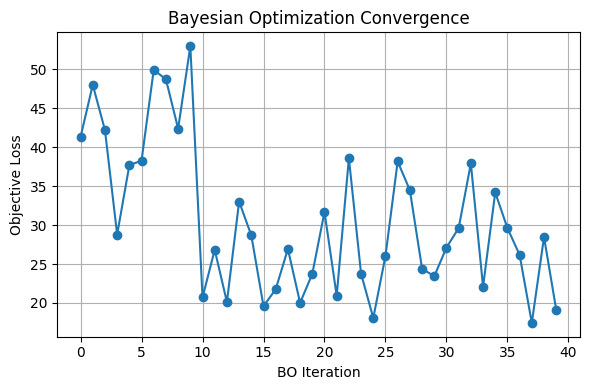

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(res.func_vals, marker="o")
plt.xlabel("BO Iteration")
plt.ylabel("Objective Loss")
plt.title("Bayesian Optimization Convergence")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


In [ ]:
X_template = X.copy()

def build_row(params):
    row = {}
    for col in X_template.columns:
        if col in params:
            row[col] = params[col]
        elif col in numeric_cols:
            row[col] = X_template[col].median()
        else:
            row[col] = X_template[col].mode()[0]
    return pd.DataFrame([row])[X_template.columns]


In [ ]:
space = [
    Real(6, 18, name="solution_concentration"),
    Real(8, 30, name="voltage_kv"),
    Real(0.1, 1.5, name="flow_rate_ml/h"),
    Real(8, 20, name="tip_collector_distance_cm"),
    Real(20, 35, name="temperature_c"),
    Real(30, 65, name="humidity_%")
]


In [ ]:
from skopt.utils import use_named_args

UNCERTAINTY_WEIGHT = 0.3
TOLERANCE = 20


In [ ]:
def make_objective(target_nm):
    @use_named_args(space)
    def objective(**params):
        X_q = build_row(params)

        preds_log = bootstrap_predict(
            rf_model, X, y_log, X_q, n_boot=50
        ).flatten()

        preds_nm = np.expm1(preds_log)
        mean = preds_nm.mean()
        std = preds_nm.std()

        loss = abs(mean - target_nm) + UNCERTAINTY_WEIGHT * std

        if not (target_nm - TOLERANCE <= mean <= target_nm + TOLERANCE):
            loss += 20

        return loss

    return objective

In [ ]:
from skopt import gp_minimize

targets = [150, 250, 300]
results = {}

for t in targets:
    res = gp_minimize(
        make_objective(t),
        space,
        n_calls=40,
        n_initial_points=10,
        random_state=42
    )
    results[t] = res


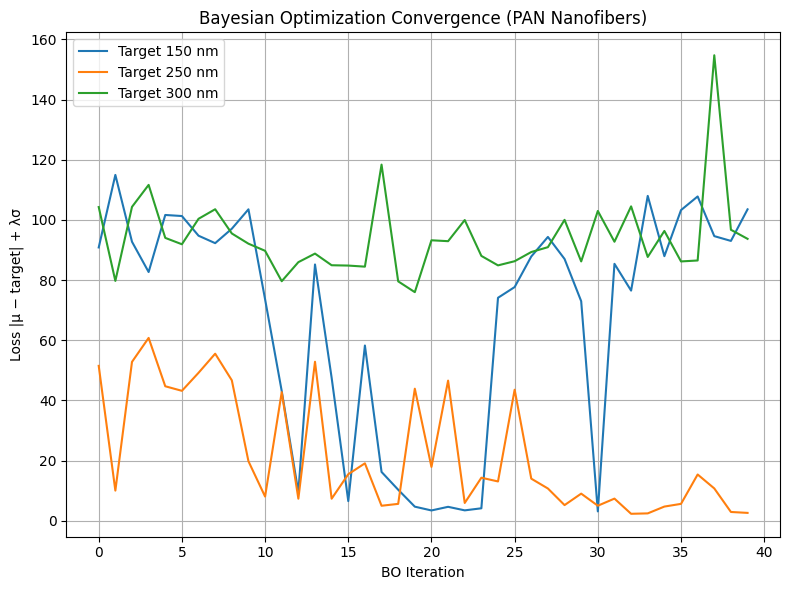

In [ ]:
plt.figure(figsize=(8,6))

for t, res in results.items():
    plt.plot(res.func_vals, label=f"Target {t} nm")

plt.xlabel("BO Iteration")
plt.ylabel("Loss |μ − target| + λσ")
plt.title("Bayesian Optimization Convergence (PAN Nanofibers)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
rows = []

for t, res in results.items():
    best_params = {dim.name: val for dim, val in zip(space, res.x)}
    best_row = build_row(best_params)

    preds_log = bootstrap_predict(
        rf_model, X, y_log, best_row, n_boot=300
    ).flatten()

    preds_nm = np.expm1(preds_log)

    rows.append({
        "Target Diameter (nm)": t,
        "Predicted Diameter (nm)": round(preds_nm.mean(), 2),
        "Uncertainty (± nm)": round(preds_nm.std(), 2),
        "90% CI Low": round(np.percentile(preds_nm, 5), 2),
        "90% CI High": round(np.percentile(preds_nm, 95), 2),
        **best_params
    })


In [ ]:
inverse_design_table = pd.DataFrame(rows)
inverse_design_table


,Target Diameter (nm),Predicted Diameter (nm),Uncertainty (± nm),90% CI Low,90% CI High,solution_concentration,voltage_kv,flow_rate_ml/h,tip_collector_distance_cm,temperature_c,humidity_%
0,150,152.18,10.32,138.39,170.83,6.000000,30.0,1.500000,8.000000,20.000000,65.000000
1,250,250.56,7.02,238.95,260.90,13.156485,30.0,0.705141,19.001153,23.066687,59.942831
2,300,245.48,5.95,235.54,254.34,11.016613,30.0,0.581951,17.536395,24.587719,53.257691


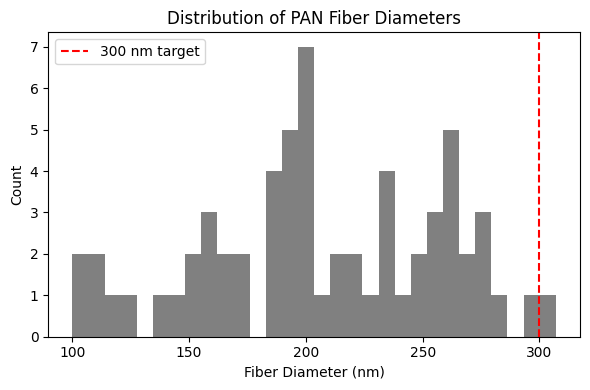

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["fiber_diameter_nm"], bins=30, color="gray")
plt.axvline(300, color="red", linestyle="--", label="300 nm target")
plt.xlabel("Fiber Diameter (nm)")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of PAN Fiber Diameters")
plt.tight_layout()
plt.show()


In [ ]:
import shap

# Extract trained components
preprocessor = rf_model.named_steps["prep"]
rf = rf_model.named_steps["rf"]

# Transform X
X_transformed = preprocessor.transform(X)

# Feature names
num_features = numeric_cols
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)

feature_names = list(num_features) + list(cat_features)


In [ ]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_transformed)


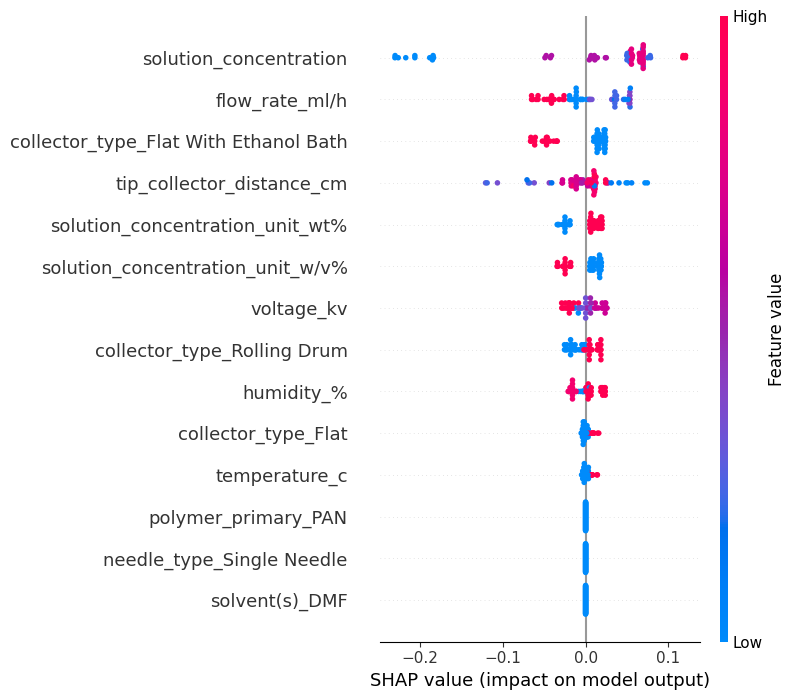

In [ ]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    show=True
)


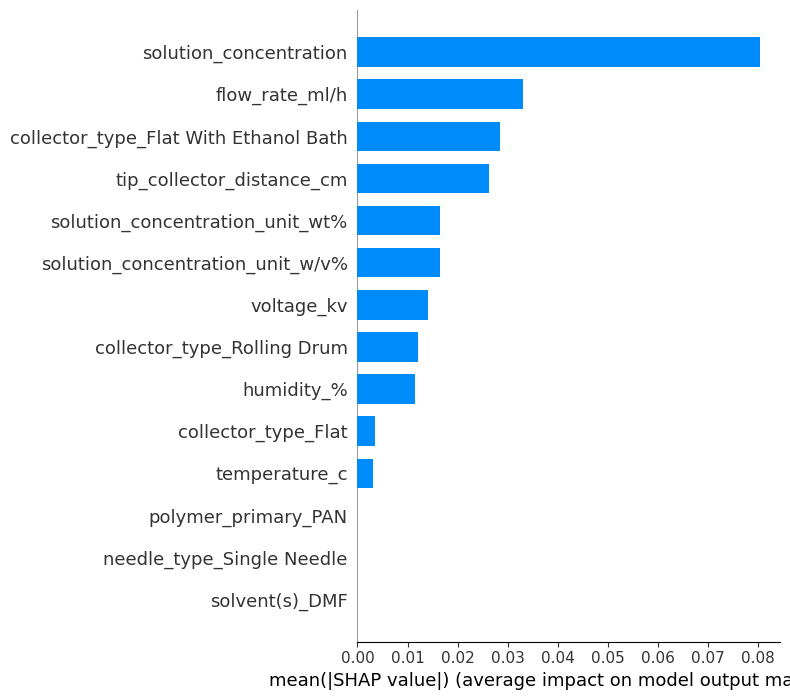

In [ ]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

